# LDLR Parameter Fitting with PyPESTO

This notebook demonstrates parameter fitting for the LDLR model using pypesto.
We fit BASE model parameters to match BOTH target functional score (uptake ratio) and abundance score (surface ratio) simultaneously.

## 1. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pypesto
import pypesto.optimize as optimize
import pypesto.visualize as visualize
from pathlib import Path
import sys

# Import our custom model
from models.ldlr_pypesto_model import (
    LDLRModelForFitting,
    create_objective_function,
    LDLR_INIT_BASE,
    K_ENDO_BASE,
    K_OFF_ENDO_BASE,
    K_RECYCLE_LDLR_BASE,
    K_LYSO_LDL_BASE,
    K_DEGRADE_LDL_BASE,
)

# Set up plotting
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

## 2. Define Variant and Target

In [2]:
# Variant configuration
VARIANT_NAME = "p.Leu8Gln"
CLUSTER = 2                     # Cluster assignment

# Target scores to fit (these are OUTPUTS from the model that we want to match)
TARGET_FUNCTIONAL_SCORE = 0.65  # Target uptake ratio relative to WT
TARGET_ABUNDANCE_SCORE = 0.80   # Target surface ratio relative to WT

# Weighting for the two objectives (adjust these to prioritize one score over the other)
WEIGHT_FUNCTIONAL = 1.0  # Weight for functional score in objective
WEIGHT_ABUNDANCE = 1.0   # Weight for abundance score in objective

# Working directory
WORK_DIR = Path("results/data/pypesto_fitting")
WORK_DIR.mkdir(parents=True, exist_ok=True)

print(f"Variant: {VARIANT_NAME}")
print(f"Cluster: {CLUSTER}")
print(f"Target functional score (uptake ratio): {TARGET_FUNCTIONAL_SCORE}")
print(f"Target abundance score (surface ratio): {TARGET_ABUNDANCE_SCORE}")
print(f"Objective weights: F={WEIGHT_FUNCTIONAL}, A={WEIGHT_ABUNDANCE}")

Variant: p.Leu8Gln
Cluster: 2
Target functional score (uptake ratio): 0.65
Target abundance score (surface ratio): 0.8
Objective weights: F=1.0, A=1.0


## 3. Define Parameter Bounds

We'll define bounds for each parameter that will be optimized.

**Strategy for better convergence:**
- Start with fewer parameters (4-5 key ones)
- Fix parameters that don't strongly affect your target scores
- Based on the model biology:
  - `LDLR_init_base` affects abundance (surface ratio)
  - `k_recycle_ldlr_base` affects abundance (receptor recycling)
  - `k_endo_base` affects functional score (uptake)
  - `k_off_surf` affects both (binding affinity)

**Current parameter set (7 parameters):**
1. LDLR_init_base - Initial LDLR receptor count
2. k_endo_base - Endocytosis rate
3. k_off_endo_base - Unbinding rate in endosome
4. k_recycle_ldlr_base - LDLR recycling rate
5. k_lyso_ldl_base - LDL lysosomal routing rate
6. k_degrade_ldl_base - LDL degradation rate
7. k_off_surf - Surface unbinding rate

💡 **Tip**: If convergence is poor, try reducing to 4 parameters:
   `LDLR_init_base`, `k_endo_base`, `k_recycle_ldlr_base`, `k_off_surf`

In [3]:
# Parameter names
param_names = [
    'LDLR_init_base',
    'k_endo_base',
    'k_off_endo_base',
    'k_recycle_ldlr_base',
    'k_lyso_ldl_base',
    'k_degrade_ldl_base',
    'k_off_surf',
]

# Default values (from the model)
param_defaults = np.array([
    LDLR_INIT_BASE,       # 1000
    K_ENDO_BASE,          # 2.0
    K_OFF_ENDO_BASE,      # 50.0
    K_RECYCLE_LDLR_BASE,  # 3.0
    K_LYSO_LDL_BASE,      # 3.0
    K_DEGRADE_LDL_BASE,   # 5.0
    1.0,                  # k_off_surf
])

# Define lower bounds (0.1x default)
lb = param_defaults * 0.1

# Define upper bounds (10x default)
ub = param_defaults * 10.0

# Create parameter DataFrame for display
param_df = pd.DataFrame({
    'Parameter': param_names,
    'Default': param_defaults,
    'Lower Bound': lb,
    'Upper Bound': ub,
})

print("Parameter bounds:")
print(param_df.to_string(index=False))

Parameter bounds:
          Parameter  Default  Lower Bound  Upper Bound
     LDLR_init_base   1000.0        100.0      10000.0
        k_endo_base      2.0          0.2         20.0
    k_off_endo_base     50.0          5.0        500.0
k_recycle_ldlr_base      3.0          0.3         30.0
    k_lyso_ldl_base      3.0          0.3         30.0
 k_degrade_ldl_base      5.0          0.5         50.0
         k_off_surf      1.0          0.1         10.0


## 4. Create Objective Function

In [4]:
# Create the objective function
# This fits BASE parameters to match BOTH target scores
obj_func, model = create_objective_function(
    variant_name=VARIANT_NAME,
    target_functional_score=TARGET_FUNCTIONAL_SCORE,
    target_abundance_score=TARGET_ABUNDANCE_SCORE,
    cluster=CLUSTER,
    work_dir=WORK_DIR,
    weight_functional=WEIGHT_FUNCTIONAL,
    weight_abundance=WEIGHT_ABUNDANCE,
)

print("Objective function created successfully!")
print(f"Fitting {len(param_names)} parameters to match both functional and abundance scores")

Objective function created successfully!
Fitting 7 parameters to match both functional and abundance scores


## 5. Test Objective Function and Check Scaling

Let's test the objective function with default parameters and check if parameter scaling might help convergence.

In [5]:
# Test with default parameters
print("Testing objective function with default parameters...")
initial_error = obj_func(param_defaults)
print(f"Initial total error (weighted sum of squared errors): {initial_error:.6f}")
print(f"Initial RMSE: {np.sqrt(initial_error):.6f}")

# Get the metrics from the last simulation
if model.last_simulation_data is not None:
    # Simulate again to get metrics
    params_dict = dict(zip(param_names, param_defaults))
    metrics = model.simulate(params_dict)
    
    print("\nInitial simulation metrics:")
    print(f"  Predicted functional score (uptake ratio): {metrics['uptake_ratio']:.4f}")
    print(f"  Target functional score: {TARGET_FUNCTIONAL_SCORE:.4f}")
    print(f"  Functional error: {(metrics['uptake_ratio'] - TARGET_FUNCTIONAL_SCORE)**2:.6f}")
    print()
    print(f"  Predicted abundance score (surface ratio): {metrics['surface_ratio']:.4f}")
    print(f"  Target abundance score: {TARGET_ABUNDANCE_SCORE:.4f}")
    print(f"  Abundance error: {(metrics['surface_ratio'] - TARGET_ABUNDANCE_SCORE)**2:.6f}")
    print()
    print(f"  Final uptake: {metrics['final_uptake']:.2f}")
    print(f"  Final surface: {metrics['final_surface']:.2f}")

# Check parameter scale differences
print("\n" + "="*60)
print("Parameter scale analysis:")
print("="*60)
print("Large differences in parameter scales can cause convergence issues.")
print(f"Parameter ranges span: {param_defaults.max() / param_defaults.min():.1f}x")
print("\nParameter scales:")
for i, (name, val) in enumerate(zip(param_names, param_defaults)):
    print(f"  {name:20s}: {val:>10.2f}  (lb={lb[i]:>8.2f}, ub={ub[i]:>10.2f})")

if param_defaults.max() / param_defaults.min() > 100:
    print("\n⚠️  Warning: Parameters span >100x in magnitude.")
    print("   Consider using log-scale for some parameters or normalizing.")

Testing objective function with default parameters...
Initial total error (weighted sum of squared errors): 0.162636
Initial RMSE: 0.403281

Initial simulation metrics:
  Predicted functional score (uptake ratio): 1.0002
  Target functional score: 0.6500
  Functional error: 0.122645

  Predicted abundance score (surface ratio): 1.0000
  Target abundance score: 0.8000
  Abundance error: 0.039991

  Final uptake: 622.12
  Final surface: 587.84

Parameter scale analysis:
Large differences in parameter scales can cause convergence issues.
Parameter ranges span: 1000.0x

Parameter scales:
  LDLR_init_base      :    1000.00  (lb=  100.00, ub=  10000.00)
  k_endo_base         :       2.00  (lb=    0.20, ub=     20.00)
  k_off_endo_base     :      50.00  (lb=    5.00, ub=    500.00)
  k_recycle_ldlr_base :       3.00  (lb=    0.30, ub=     30.00)
  k_lyso_ldl_base     :       3.00  (lb=    0.30, ub=     30.00)
  k_degrade_ldl_base  :       5.00  (lb=    0.50, ub=     50.00)
  k_off_surf       

## 6. Set Up PyPESTO Problem

In [6]:
# Create pypesto objective (without gradients for now)
pypesto_objective = pypesto.Objective(fun=obj_func)

# Alternative: Add finite difference gradients for optimizers that need them
# Uncomment these lines to enable gradients:
# from pypesto.objective.finite_difference import FD
# pypesto_objective = pypesto.Objective(
#     fun=obj_func,
#     grad=FD(obj_func, method='central'),  # Central finite differences
# )

# Create pypesto problem
problem = pypesto.Problem(
    objective=pypesto_objective,
    lb=lb,
    ub=ub,
    x_names=param_names,
)

print("PyPESTO problem created successfully!")
print(f"Number of parameters: {problem.dim}")
print(f"Parameter names: {problem.x_names}")
print(f"Gradients enabled: {pypesto_objective.has_grad}")

PyPESTO problem created successfully!
Number of parameters: 7
Parameter names: ['LDLR_init_base', 'k_endo_base', 'k_off_endo_base', 'k_recycle_ldlr_base', 'k_lyso_ldl_base', 'k_degrade_ldl_base', 'k_off_surf']
Gradients enabled: False


## 7. Run Optimization

We'll use multiple optimizers and starting points to find the best fit.

In [8]:
# Choose optimizer
# For complex problems without analytical gradients, use gradient-free or finite-difference methods

# Option 1: Scipy with trust-constr (handles constraints well, uses finite differences)
optimizer = optimize.ScipyOptimizer(
    method='L-BFGS-B', #trust-constr',  # Good for constrained optimization
    options={
        'maxiter': 1000,
        'verbose': 1,        # Show progress
    }
)
optimizer_name = "Scipy trust-constr"

# Option 2: If you want to try Fides with finite difference gradients:
# from pypesto.objective.finite_difference import FD
# pypesto_objective_with_grad = pypesto.Objective(
#     fun=obj_func,
#     grad=FD(obj_func, method='central')  # Finite difference gradients
# )
# optimizer = optimize.FidesOptimizer(verbose=1)
# optimizer_name = "Fides (with FD gradients)"

# Option 3: Particle Swarm (gradient-free, global optimizer)
# Uncomment to try:
# try:
#     from pypesto.optimize import PyswarmOptimizer
#     optimizer = PyswarmOptimizer()
#     optimizer_name = "Particle Swarm (gradient-free)"
# except ImportError:
#     pass  # Use default optimizer above

# Number of starts (multi-start optimization)
n_starts = 10

# Enable history recording for visualization
history_options = pypesto.HistoryOptions(trace_record=True)

print(f"Running optimization with {n_starts} starts...")
print(f"Optimizer: {optimizer_name}")
print("This may take several minutes...\n")

# Run optimization
result = optimize.minimize(
    problem=problem,
    optimizer=optimizer,
    n_starts=n_starts,
    history_options=history_options,
)

print("\nOptimization complete!")
print(f"Best objective value: {result.optimize_result.fval[0]:.8f}")

Running optimization with 10 starts...
Optimizer: Scipy trust-constr
This may take several minutes...



  0%|          | 0/10 [00:00<?, ?it/s]/Users/faeder/miniconda3/lib/python3.12/site-packages/pypesto/optimize/optimizer.py:503: OptimizeWarning: Unknown solver options: verbose
  res = scipy.optimize.minimize(
 10%|█         | 1/10 [00:01<00:12,  1.38s/it]/Users/faeder/miniconda3/lib/python3.12/site-packages/pypesto/optimize/optimizer.py:503: OptimizeWarning: Unknown solver options: verbose
  res = scipy.optimize.minimize(
 20%|██        | 2/10 [00:02<00:10,  1.36s/it]/Users/faeder/miniconda3/lib/python3.12/site-packages/pypesto/optimize/optimizer.py:503: OptimizeWarning: Unknown solver options: verbose
  res = scipy.optimize.minimize(
 30%|███       | 3/10 [00:04<00:09,  1.37s/it]/Users/faeder/miniconda3/lib/python3.12/site-packages/pypesto/optimize/optimizer.py:503: OptimizeWarning: Unknown solver options: verbose
  res = scipy.optimize.minimize(
 40%|████      | 4/10 [00:05<00:08,  1.35s/it]/Users/faeder/miniconda3/lib/python3.12/site-packages/pypesto/optimize/optimizer.py:503: Optim


Optimization complete!
Best objective value: 0.21268568


## 8. Analyze Results

In [9]:
# Get best parameters
best_params = result.optimize_result.x[0]
best_fval = result.optimize_result.fval[0]

print("Best fit parameters:")
print("=" * 60)
results_df = pd.DataFrame({
    'Parameter': param_names,
    'Default': param_defaults,
    'Optimized': best_params,
    'Ratio (Opt/Default)': best_params / param_defaults,
})
print(results_df.to_string(index=False))
print("\n" + "=" * 60)
print(f"Best objective value (total error): {best_fval:.8f}")
print(f"Best RMSE: {np.sqrt(best_fval):.8f}")

# Run simulation with best parameters
best_params_dict = dict(zip(param_names, best_params))
best_metrics = model.simulate(best_params_dict)

print("\nBest fit metrics:")
print("=" * 60)
print("FUNCTIONAL SCORE (uptake ratio):")
print(f"  Predicted: {best_metrics['uptake_ratio']:.6f}")
print(f"  Target:    {TARGET_FUNCTIONAL_SCORE:.6f}")
print(f"  Error:     {abs(best_metrics['uptake_ratio'] - TARGET_FUNCTIONAL_SCORE):.6f}")
print(f"  % Error:   {100*abs(best_metrics['uptake_ratio'] - TARGET_FUNCTIONAL_SCORE)/TARGET_FUNCTIONAL_SCORE:.2f}%")
print()
print("ABUNDANCE SCORE (surface ratio):")
print(f"  Predicted: {best_metrics['surface_ratio']:.6f}")
print(f"  Target:    {TARGET_ABUNDANCE_SCORE:.6f}")
print(f"  Error:     {abs(best_metrics['surface_ratio'] - TARGET_ABUNDANCE_SCORE):.6f}")
print(f"  % Error:   {100*abs(best_metrics['surface_ratio'] - TARGET_ABUNDANCE_SCORE)/TARGET_ABUNDANCE_SCORE:.2f}%")

Best fit parameters:
          Parameter  Default   Optimized  Ratio (Opt/Default)
     LDLR_init_base   1000.0 1048.473191             1.048473
        k_endo_base      2.0   18.755711             9.377856
    k_off_endo_base     50.0   36.929042             0.738581
k_recycle_ldlr_base      3.0    8.183793             2.727931
    k_lyso_ldl_base      3.0   22.699860             7.566620
 k_degrade_ldl_base      5.0   12.839079             2.567816
         k_off_surf      1.0    9.027485             9.027485

Best objective value (total error): 0.21268568
Best RMSE: 0.46117857

Best fit metrics:
FUNCTIONAL SCORE (uptake ratio):
  Predicted: 0.995017
  Target:    0.650000
  Error:     0.345017
  % Error:   53.08%

ABUNDANCE SCORE (surface ratio):
  Predicted: 0.493979
  Target:    0.800000
  Error:     0.306021
  % Error:   38.25%


## 9. Visualize Optimization Results

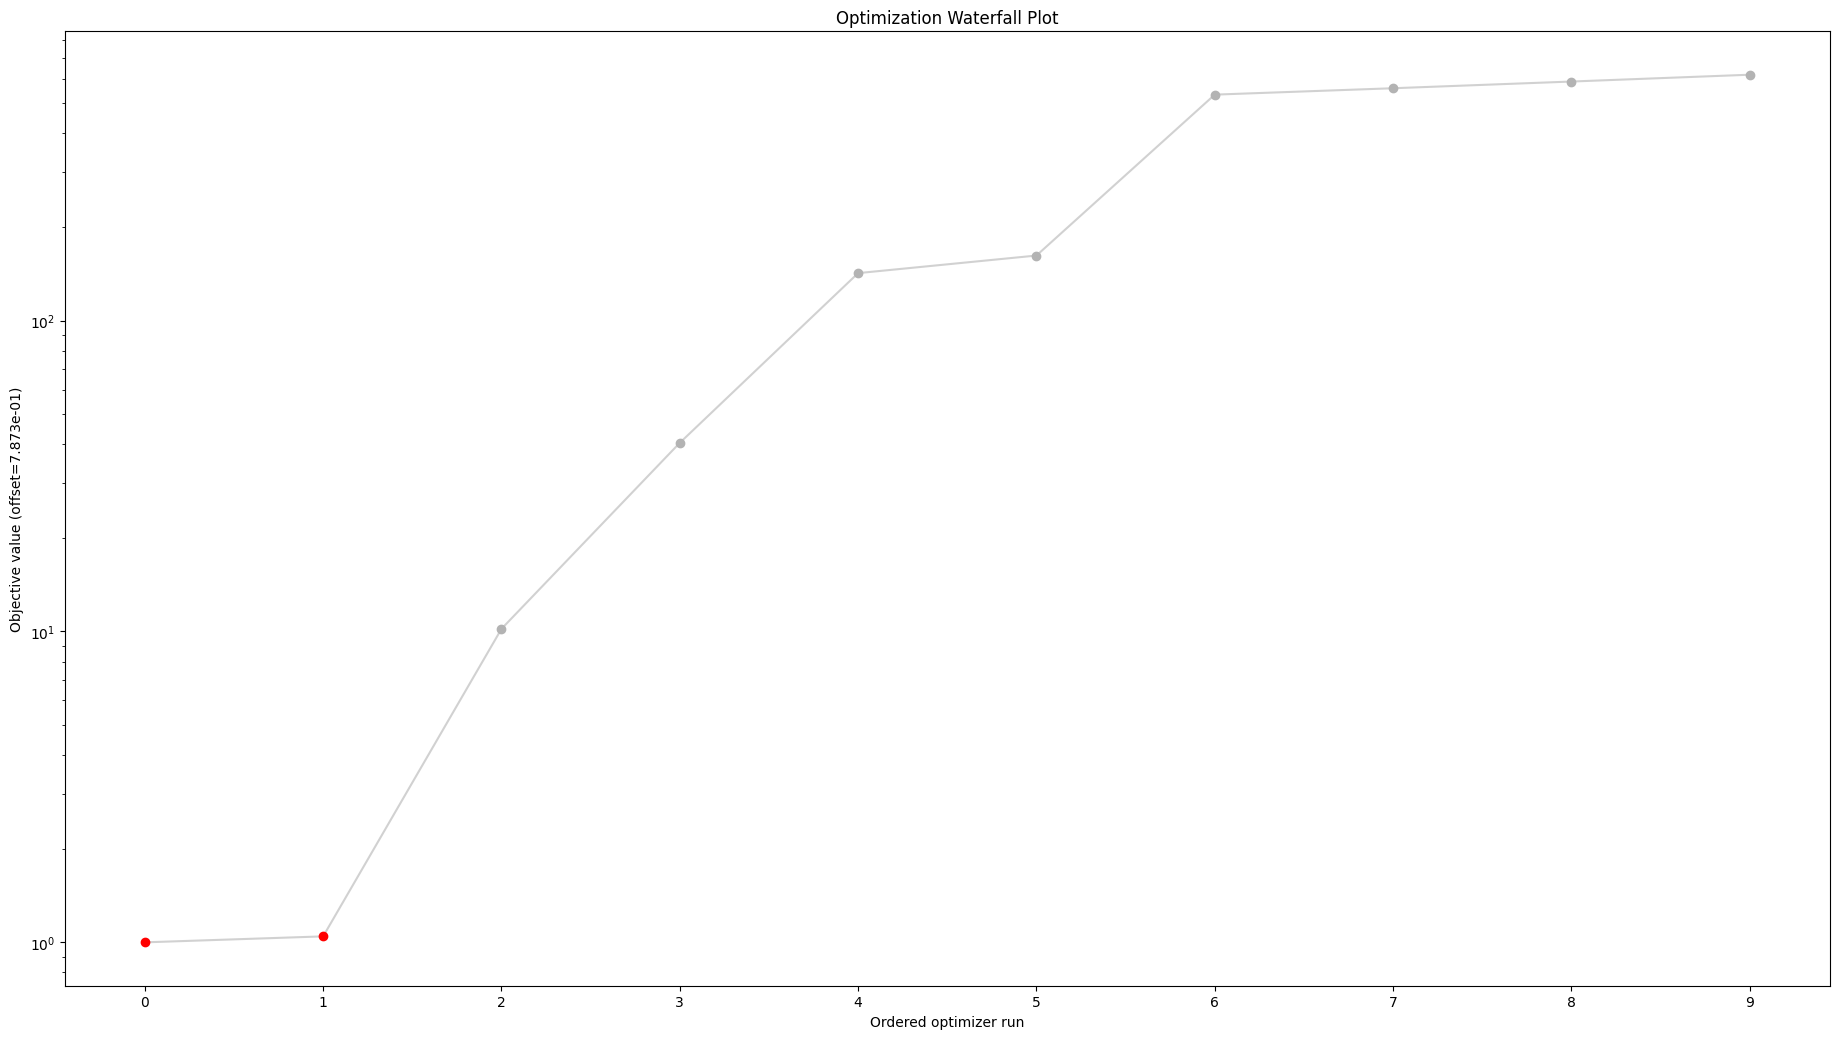

In [10]:
# Waterfall plot - shows objective values for all starts
visualize.waterfall(result)
plt.title('Optimization Waterfall Plot')
plt.tight_layout()
plt.show()

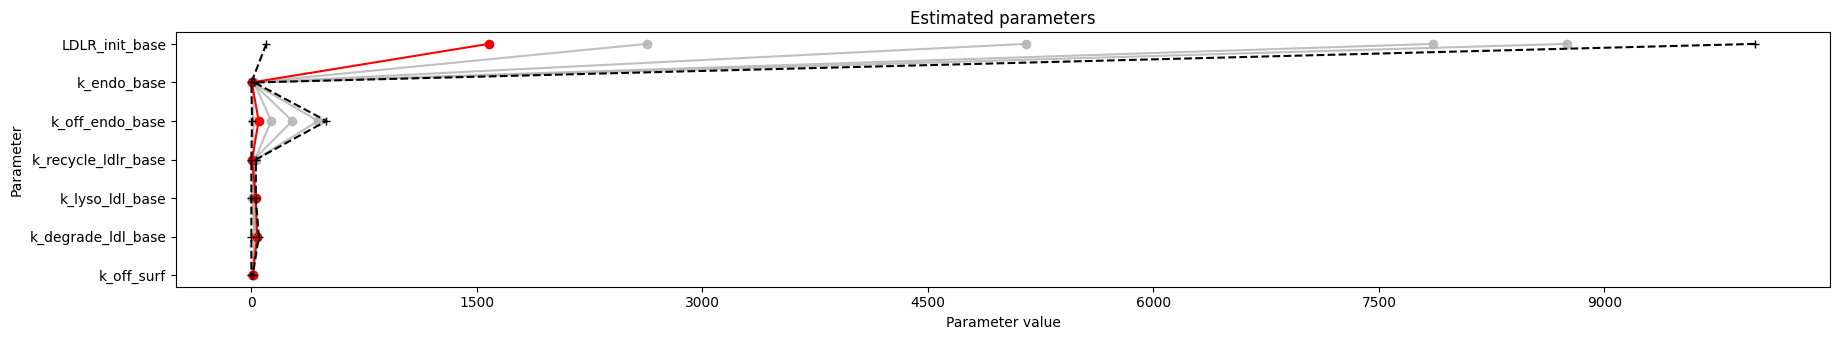

In [ ]:
# Parameter plot - shows optimized parameters from all starts
visualize.parameters(result)
plt.tight_layout()
plt.show()

In [ ]:
# Optimizer history - shows convergence
visualize.optimizer_history(result)
plt.tight_layout()
plt.show()

ValueError: No function value trace has been recorded.

## 10. Simulate with Best Parameters

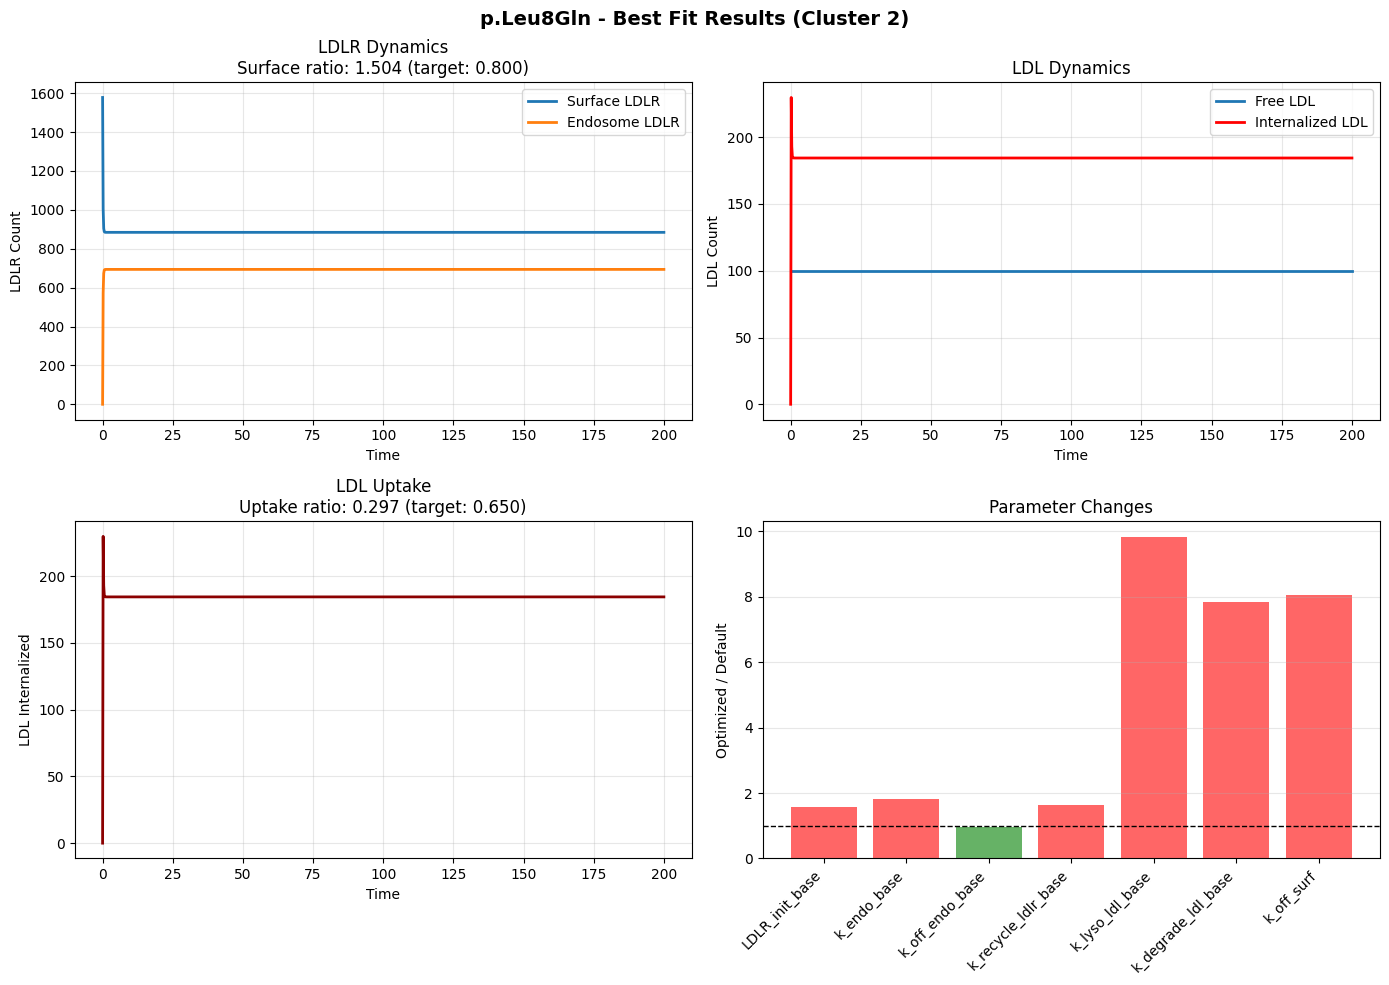

In [ ]:
# Get the simulation data
sim_data = model.last_simulation_data

# Plot results
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# LDLR dynamics
axes[0, 0].plot(sim_data['time'], sim_data['LDLR_surface'], label='Surface LDLR', linewidth=2)
axes[0, 0].plot(sim_data['time'], sim_data['LDLR_endosome'], label='Endosome LDLR', linewidth=2)
axes[0, 0].set_xlabel('Time')
axes[0, 0].set_ylabel('LDLR Count')
axes[0, 0].set_title(f'LDLR Dynamics\nSurface ratio: {best_metrics["surface_ratio"]:.3f} (target: {TARGET_ABUNDANCE_SCORE:.3f})')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# LDL dynamics
axes[0, 1].plot(sim_data['time'], sim_data['LDL_free'], label='Free LDL', linewidth=2)
axes[0, 1].plot(sim_data['time'], sim_data['LDL_internalized'], 
               label='Internalized LDL', linewidth=2, color='red')
axes[0, 1].set_xlabel('Time')
axes[0, 1].set_ylabel('LDL Count')
axes[0, 1].set_title('LDL Dynamics')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# LDL uptake
axes[1, 0].plot(sim_data['time'], sim_data['LDL_internalized'], 
               linewidth=2, color='darkred')
axes[1, 0].set_xlabel('Time')
axes[1, 0].set_ylabel('LDL Internalized')
axes[1, 0].set_title(f'LDL Uptake\nUptake ratio: {best_metrics["uptake_ratio"]:.3f} (target: {TARGET_FUNCTIONAL_SCORE:.3f})')
axes[1, 0].grid(alpha=0.3)

# Parameter comparison
x_pos = np.arange(len(param_names))
ratios = best_params / param_defaults
colors = ['green' if r < 1 else 'red' if r > 1 else 'gray' for r in ratios]
axes[1, 1].bar(x_pos, ratios, color=colors, alpha=0.6)
axes[1, 1].axhline(y=1.0, color='black', linestyle='--', linewidth=1)
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(param_names, rotation=45, ha='right')
axes[1, 1].set_ylabel('Optimized / Default')
axes[1, 1].set_title('Parameter Changes')
axes[1, 1].grid(alpha=0.3, axis='y')

plt.suptitle(f'{VARIANT_NAME} - Best Fit Results (Cluster {CLUSTER})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Save Results

In [ ]:
# Save results to CSV
output_file = WORK_DIR / f"{VARIANT_NAME}_fitted_parameters.csv"
results_df.to_csv(output_file, index=False)
print(f"Results saved to: {output_file}")

# Save metrics
metrics_file = WORK_DIR / f"{VARIANT_NAME}_metrics.txt"
with open(metrics_file, 'w') as f:
    f.write(f"Variant: {VARIANT_NAME}\n")
    f.write(f"Cluster: {CLUSTER}\n")
    f.write(f"\nTarget scores:\n")
    f.write(f"  Target functional score (uptake ratio): {TARGET_FUNCTIONAL_SCORE}\n")
    f.write(f"  Target abundance score (surface ratio): {TARGET_ABUNDANCE_SCORE}\n")
    f.write(f"\nBest fit metrics:\n")
    f.write(f"  Predicted functional score: {best_metrics['uptake_ratio']:.6f}\n")
    f.write(f"  Functional error: {abs(best_metrics['uptake_ratio'] - TARGET_FUNCTIONAL_SCORE):.6f}\n")
    f.write(f"  Predicted abundance score: {best_metrics['surface_ratio']:.6f}\n")
    f.write(f"  Abundance error: {abs(best_metrics['surface_ratio'] - TARGET_ABUNDANCE_SCORE):.6f}\n")
    f.write(f"\nSimulation outputs:\n")
    f.write(f"  Final uptake: {best_metrics['final_uptake']:.2f}\n")
    f.write(f"  Final surface: {best_metrics['final_surface']:.2f}\n")
    f.write(f"\nOptimization:\n")
    f.write(f"  Total objective value: {best_fval:.8f}\n")
    f.write(f"  RMSE: {np.sqrt(best_fval):.8f}\n")
    f.write(f"  Weight functional: {WEIGHT_FUNCTIONAL}\n")
    f.write(f"  Weight abundance: {WEIGHT_ABUNDANCE}\n")
    
print(f"Metrics saved to: {metrics_file}")

## Next Steps

### If Convergence is Poor

**Common Issues and Solutions:**

1. **Too many parameters** (7 parameters for 2 objectives)
   - Fix some parameters at known values to reduce dimensionality
   - Example: Fix `k_lyso_ldl_base` and `k_degrade_ldl_base` at defaults
   
2. **Parameter scaling issues** (LDLR_init ~1000, other params ~1-50)
   - Use normalized/scaled parameters
   - Work in log-space for parameters with wide ranges
   
3. **Flat objective landscape**
   - Some parameters may not strongly affect both scores
   - Try sensitivity analysis to identify important parameters
   
4. **Local minima**
   - Increase `n_starts` to 20-50 for better global search
   - Try different optimizers (Fides, scipy trust-constr, ipopt)

**Quick Fixes to Try:**

```python
# Option 1: Reduce parameter count by fixing some parameters
# Modify parameter_bounds cell to only fit key parameters:
# LDLR_init_base, k_endo_base, k_recycle_ldlr_base, k_off_surf

# Option 2: Adjust weight balance if one score is much harder to fit
WEIGHT_FUNCTIONAL = 2.0  # Prioritize functional score
WEIGHT_ABUNDANCE = 1.0

# Option 3: Use tighter parameter bounds based on biology
# Instead of 0.1x-10x, use 0.5x-2x if you have prior knowledge

# Option 4: Try different optimizer
from pypesto.optimize import IpoptOptimizer
optimizer = IpoptOptimizer()
```

### Optimization Improvements
1. **Adjust parameter bounds**: If optimized parameters hit the bounds, consider widening them
2. **Try different optimizers**: PyPESTO supports many optimizers:
   - `fides`: Trust-region optimizer (often better for nonlinear problems) ⭐
   - `scipy` methods: L-BFGS-B, TNC, SLSQP, trust-constr
   - `ipopt`: Interior point optimizer (needs ipopt installed)
3. **Increase n_starts**: More starting points help find global optimum (try 20-50)
4. **Adjust weights**: Change `WEIGHT_FUNCTIONAL` and `WEIGHT_ABUNDANCE` to prioritize one score
5. **Add parameter constraints**: Use pypesto constraints for mechanistic relationships

### Analysis and Validation
6. **Profile likelihood**: Use `pypesto.profile` to assess parameter identifiability
7. **Uncertainty analysis**: Use `pypesto.sample` for Bayesian uncertainty quantification
8. **Ensemble analysis**: Examine all optimization results, not just the best
9. **Sensitivity analysis**: Test how changes in parameters affect both scores

### Batch Fitting
10. **Fit multiple variants**: Create a loop to fit parameters for all variants in your dataset
11. **Compare across clusters**: Analyze how optimal parameters differ by cluster assignment

### Model Refinement
12. **Fix certain parameters**: If some parameters are well-known, remove them from optimization
13. **Add more parameters**: Include module strengths (strength_LA3, strength_LA4, etc.) in fitting
14. **Multi-objective optimization**: Use Pareto optimization if trade-offs exist between scores